# SECTOR ANALYSIS - Technology

check if makes sense: https://www.spglobal.com/spdji/en/index-family/equity/us-equity/sp-sectors/#overview


In [1]:
import pandas as pd
from pathlib import Path
import os

os.chdir(Path.cwd().parent.parent)

sector_name = "Technology"
save_path= "backtest/attachments"


In [2]:
df = pd.read_csv("backtest/data/backtest_data.csv")
df = df[df["sector"] == sector_name]

Gespeichert: backtest/attachments/technology/value_score_Renditedreieck.png


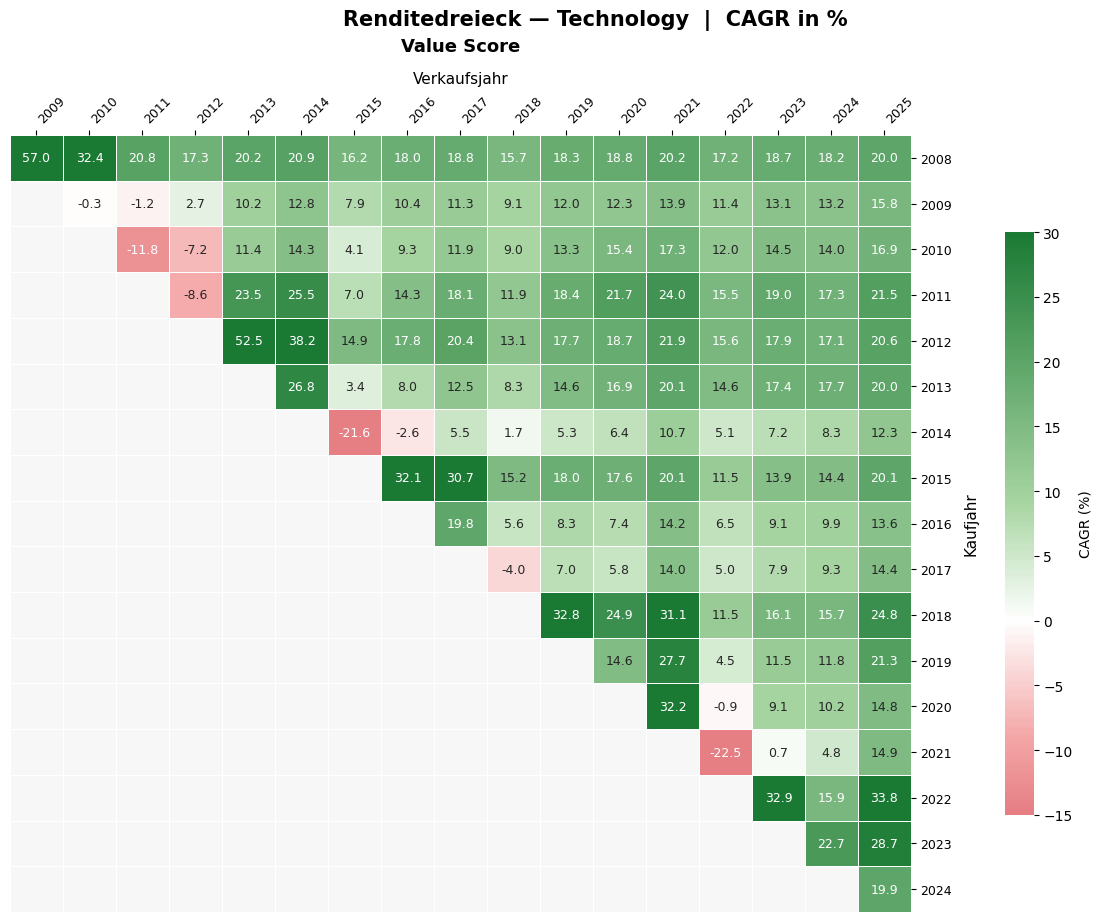

In [3]:
from backtest.renditedreieck import plot_renditedreieck

plot_renditedreieck(df, sector_name, "value_score", label="Value Score", save_path=save_path)

Gespeichert: backtest/attachments/technology/momentum_score_Renditedreieck.png


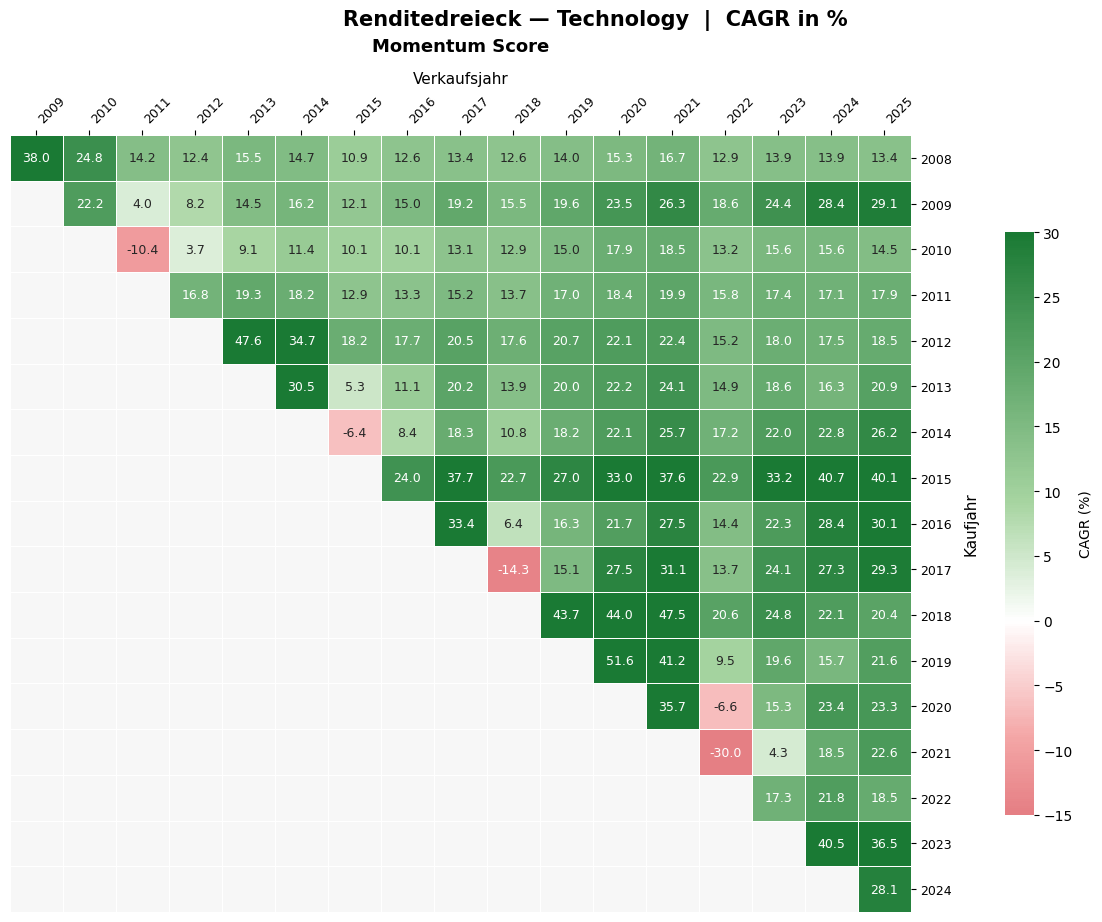

In [4]:
plot_renditedreieck(df, sector_name, "momentum_score", label="Momentum Score", save_path=save_path)

Gespeichert: backtest/attachments/technology/delta_Deltadreieck.png


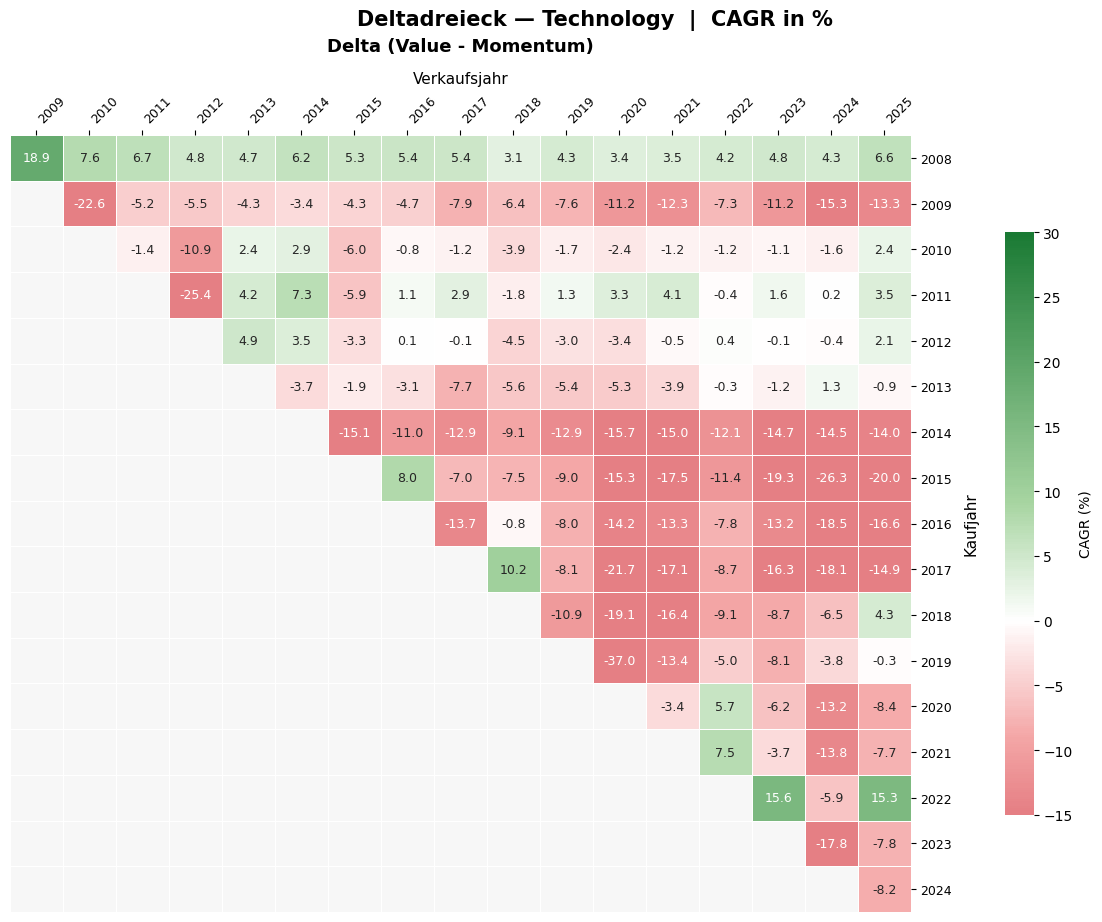

In [5]:

df_value = df[df["strategy"] == "value_score"].set_index(["buyyear", "sellyear", "sector"])["rendite"]
df_mom   = df[df["strategy"] == "momentum_score"].set_index(["buyyear", "sellyear", "sector"])["rendite"]


df_delta = (df_value - df_mom).reset_index()
df_delta.columns = ["buyyear", "sellyear", "sector", "rendite"]
df_delta["strategy"] = "delta"  # damit plot_renditedreieck funktioniert

plot_renditedreieck(df_delta, sector_name, "delta", label="Delta (Value - Momentum)", titel="Deltadreieck", save_path=save_path)


## 1, 3, 5 Jahres Ansicht


In [6]:
import plotly.express as px

In [7]:
df["horizon"] = df["sellyear"] - df["buyyear"]

df = df[df["horizon"].isin([1,3,5])]

horizons = [1,3,5]

print(df.pivot_table(
    index="sellyear",
    columns=["strategy", "horizon"],
    values="rendite"
    ).describe().T)

for h in horizons:
    df_filtered = df[df["horizon"] == h]
    
    fig = px.box(
        df_filtered,
        x="strategy",
        y="rendite",
        title=f"{h}-Jahres Rendite nach Strategie ",
        color="strategy",  # sorgt für unterschiedliche Farben
        color_discrete_sequence=px.colors.qualitative.Set2,
        points="all" 
    )
    fig.update_yaxes(title="Rendite (%)")
    fig.update_xaxes(title="Strategy")



    fig.update_layout(
        width=900,
        height=500,
        title_font_size=20,
        font=dict(size=14),
        template="simple_white",
        showlegend=False
    )
   
    fig.show()
    output_dir = Path(save_path) / sector_name.lower().replace(" ", "_")
    output_dir.mkdir(parents=True, exist_ok=True)

    file_path = output_dir / f"{h}_year_distribution.png"
    fig.write_image(file_path)


                        count       mean        std    min     25%    50%  \
strategy       horizon                                                      
momentum_score 1         17.0  21.673529  23.669581 -30.00  16.770  28.08   
               3         15.0  18.204667   9.648468   8.18  12.640  18.16   
               5         13.0  18.893077   6.580950  10.05  13.920  16.23   
value_score    1         17.0  16.143529  24.030726 -22.52  -4.030  19.92   
               3         15.0  13.426667  10.019633   2.68   5.605   9.13   
               5         13.0  12.694615   5.559154   4.06   8.340  14.18   

                           75%    max  
strategy       horizon                 
momentum_score 1        38.030  51.64  
               3        18.495  47.52  
               5        23.290  32.95  
value_score    1        32.250  56.95  
               3        18.035  33.81  
               5        16.090  20.42  
